<a href="https://colab.research.google.com/github/elvispreakerebi/ml-pipeline-formative-1/blob/nformi/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
#environmental setup and importing all nccessary libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)

In [3]:
from google.colab import drive #mounting the drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!ls /content/drive/MyDrive/Ecommerceformative

'archive (6).zip'


In [5]:
!unzip -o '/content/drive/MyDrive/Ecommerceformative/archive (6).zip' -d /content/data

Archive:  /content/drive/MyDrive/Ecommerceformative/archive (6).zip
  inflating: /content/data/ecommerce_sales_data.csv  


In [6]:
!ls /content/data

ecommerce_sales_data.csv


In [15]:
pd.read_csv('/content/data/ecommerce_sales_data.csv')

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28
...,...,...,...,...,...,...,...
3495,2023-02-15,Monitor,Accessories,North,4,4064,771.16
3496,2022-09-18,Monitor,Accessories,East,1,1117,119.89
3497,2022-04-12,Laptop,Electronics,South,4,260,66.02
3498,2022-01-18,Printer,Office,South,3,222,50.28


In [16]:
df = pd.read_csv('/content/data/ecommerce_sales_data.csv')
df.info() #checkong for null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


#dataset looks good, with no null values all 3500 entries are non-null values bu the order date needs a needs datetime conversion

In [17]:
#converting the order date to date and time
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [18]:
#aggregating to daily level
daily_df = df.resample('D', on='Order Date').agg(
    {
        'Sales': 'sum',
        'Quantity': 'sum',
        'Profit': 'sum'
    }
)

In [19]:
#ensuring that there is continious daily dates
daily_df=daily_df.asfreq('D')
daily_df.fillna(0, inplace=True)

In [20]:
#checking for time range
print('start date:', daily_df.index.min())
print('end date:', daily_df.index.max())
print('total daya:', len(daily_df))
#

start date: 2022-01-01 00:00:00
end date: 2024-12-31 00:00:00
total daya: 1096


In [21]:
df.describe() #statistical overview of the numerical data/ DataFrame containing count, mean, standard deviation

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571648,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


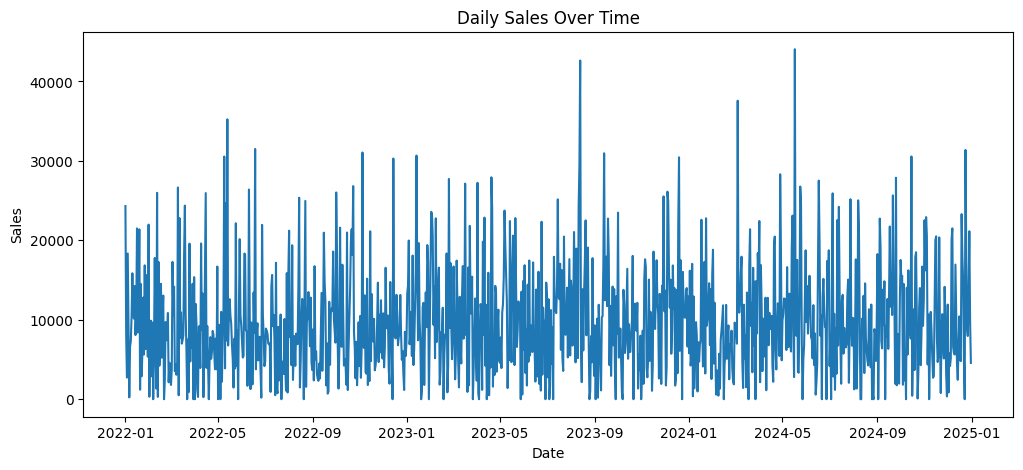

In [22]:
plt.figure(figsize=(12,5))
plt.plot(daily_df.index, daily_df['Sales'])
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

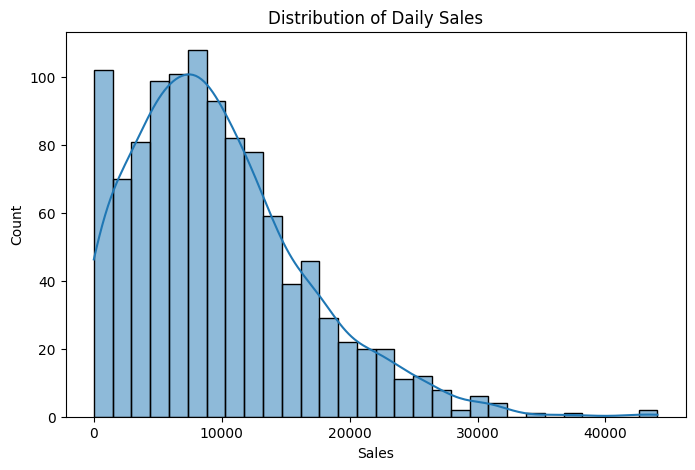

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(daily_df['Sales'], bins=30, kde=True)
plt.title("Distribution of Daily Sales")
plt.show()

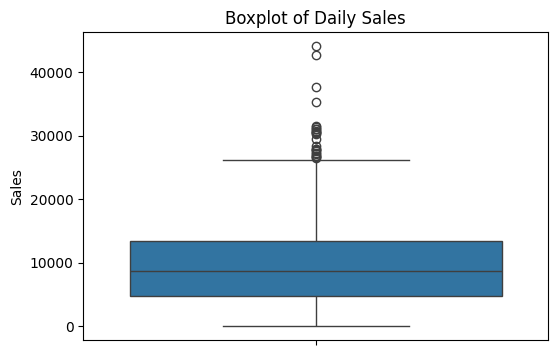

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(y=daily_df['Sales'])
plt.title("Boxplot of Daily Sales")
plt.show()

#Question 1 — Long-Term Trend (30-Day Moving Average)

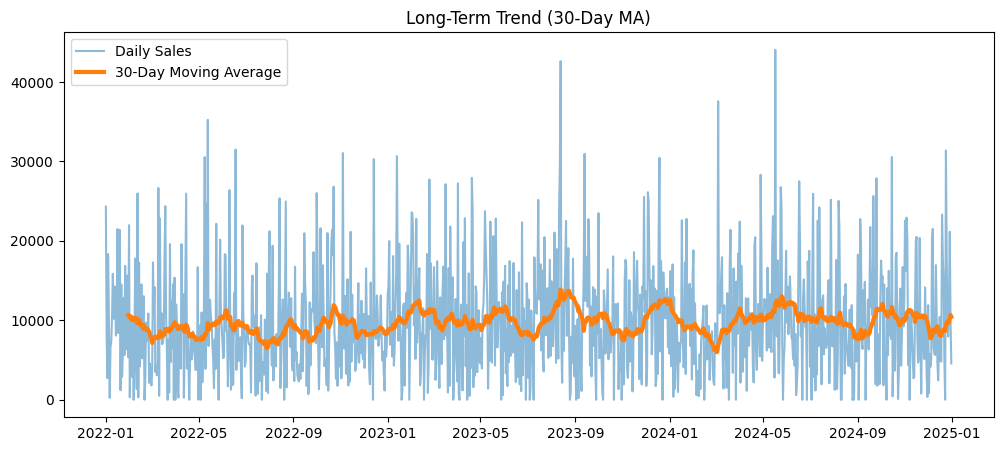

In [25]:
daily_df['MA_30'] = daily_df['Sales'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_df['Sales'], label='Daily Sales', alpha=0.5)
plt.plot(daily_df['MA_30'], label='30-Day Moving Average', linewidth=3)
plt.legend()
plt.title("Long-Term Trend (30-Day MA)")
plt.show()

#Question 2 — Weekly Seasonality (Lag 7)

In [29]:
daily_df['Lag_7'] = daily_df['Sales'].shift(7)

correlation_lag7 = daily_df[['Sales','Lag_7']].corr()
correlation_lag7

,Sales,Lag_7
Sales,1.00000,0.00444
Lag_7,0.00444,1.00000


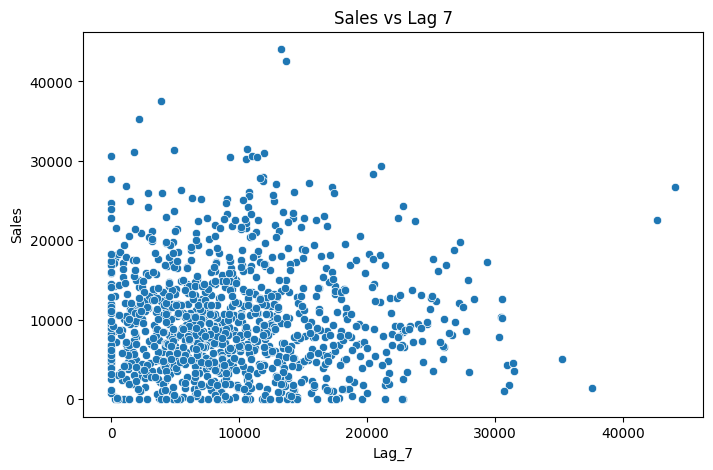

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=daily_df['Lag_7'], y=daily_df['Sales'])
plt.title("Sales vs Lag 7")
plt.show()

In [31]:
daily_df['Lag_1'] = daily_df['Sales'].shift(1)

correlation_lag1 = daily_df[['Sales','Lag_1']].corr()
correlation_lag1

,Sales,Lag_1
Sales,1.000000,0.018281
Lag_1,0.018281,1.000000


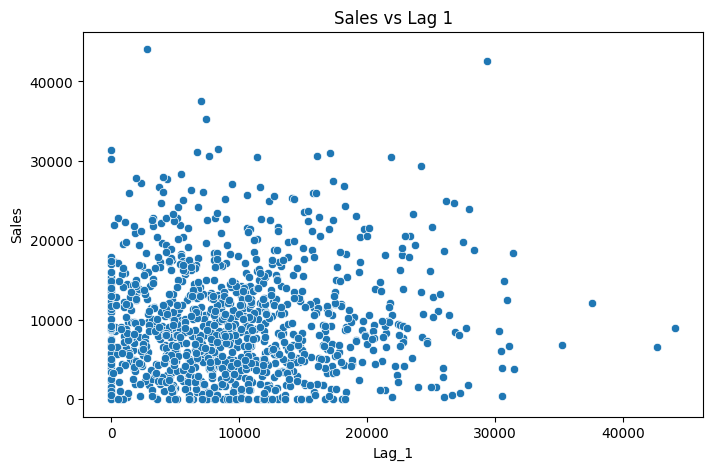

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=daily_df['Lag_1'], y=daily_df['Sales'])
plt.title("Sales vs Lag 1")
plt.show()

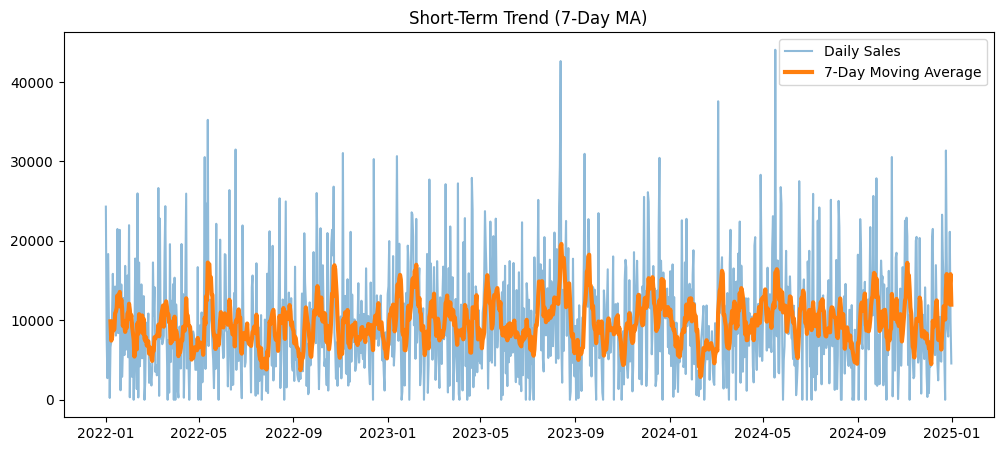

In [33]:
daily_df['MA_7'] = daily_df['Sales'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_df['Sales'], label='Daily Sales', alpha=0.5)
plt.plot(daily_df['MA_7'], label='7-Day Moving Average', linewidth=3)
plt.legend()
plt.title("Short-Term Trend (7-Day MA)")
plt.show()

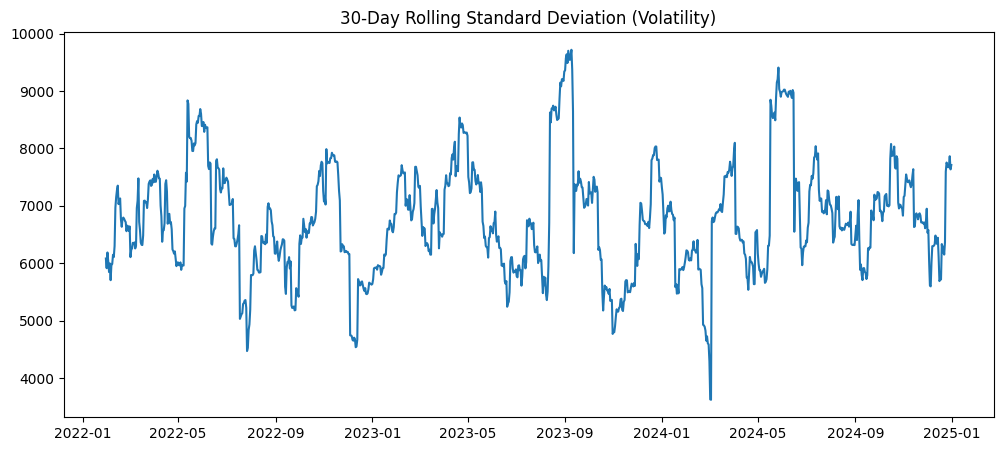

In [34]:
daily_df['Rolling_Std_30'] = daily_df['Sales'].rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(daily_df['Rolling_Std_30'])
plt.title("30-Day Rolling Standard Deviation (Volatility)")
plt.show()